In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

from FEX.models import fex
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
from generate_data import make_data, make_adjacency
timesteps=5000
adj_matrix = make_adjacency(100, 0.03, device='cpu')
timeseries, t_derivs = make_data(num_samples=5000, adjacency=adj_matrix, snr=45)

In [7]:
# print average degree
print(adj_matrix.sum() / adj_matrix.size(0))

tensor(2.9000)


In [ ]:
dimx_fex = fex.CoupledFEX('depth_3_leaves_4_config', 'depth_2_tree_config', 0, controller_epochs=120, controller_lr=0.005, finetune_epochs=20000, finetune_lr=1e-4, num_fex_epochs=120, self_lr=0.02, inter_lr=0.02, bfgs_epochs=20, bfgs_lr=0.65, poolsize=8, device=device, expression_threshold=0.1)
dimx_fex.fit(timeseries, t_derivs, adj_matrix, num_workers=5, finetune_bs=512)

Using 5 parallel processes for candidate evaluation.
Using device: cudaUsing device: cuda

Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 2 on GPU 0
Using device: cuda
Evaluating candidate 3 on GPU 0
Using device: cuda
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.10 seconds
Epoch 0 pmfs: [array([[0.30694672, 0.3384263 , 0.35462698]], dtype=float32), array([[0.3124191 , 0.36171272, 0.3258682 ]], dtype=float32), array([[0.3173938 , 0.32865047, 0.35395575]], dtype=float32), array([[0.15937857, 0.12601742, 0.15177155, 0.15438269, 0.13777103,
        0.12841198, 0.14226675]], dtype=float32), array([[0.15710327, 0.12756014, 0.1402081 , 0.14112827, 0.1456982 ,
        0.15152349, 0.13677853]], dtype=float32), array([[0.14404166, 0.14917937, 0.14221935, 0.14349

In [ ]:
dimy_fex = fex.SingleFEX('depth_3_leaves_4_config', 1, num_finetune_epochs=5000, controller_epochs=250, num_fex_epochs=80, device=device)
dimy_fex.fit(timeseries, t_derivs, num_workers=5)

Using 5 parallel processes for candidate evaluation.
Using device: cuda
Using device: cuda
Using device: cuda
Using device: cuda
Using device: cuda
Evaluation time for fex epoch: 0.07 seconds
Epoch 0, pmfs: [array([[0.25680146, 0.26132765, 0.23977694, 0.24209392]], dtype=float32), array([[0.26348305, 0.24736461, 0.22275795, 0.26639438]], dtype=float32), array([[0.25243562, 0.29476568, 0.21750788, 0.23529088]], dtype=float32), array([[0.1452939 , 0.14429331, 0.14114612, 0.15778783, 0.12763426,
        0.15174535, 0.13209921]], dtype=float32), array([[0.12985681, 0.1268347 , 0.13715221, 0.15752229, 0.15547985,
        0.16045797, 0.13269624]], dtype=float32), array([[0.15018559, 0.1542774 , 0.14435062, 0.13920602, 0.12997274,
        0.12642066, 0.15558696]], dtype=float32), array([[0.15233015, 0.14425123, 0.1543588 , 0.13386136, 0.1375041 ,
        0.13711494, 0.14057942]], dtype=float32)]
Evaluation time for fex epoch: 0.09 seconds
Epoch 1, pmfs: [array([[0.26856732, 0.27488443, 0.2263

In [ ]:
dimz_fex = fex.SingleFEX('depth_3_leaves_4_config', 2, num_finetune_epochs=5000, num_fex_epochs=65, device=device)
dimz_fex.fit(timeseries, t_derivs, num_workers=5)

Using 5 parallel processes for candidate evaluation.
Using device: cuda
Using device: cuda
Using device: cuda
Using device: cuda
Using device: cuda
Evaluation time for fex epoch: 0.07 seconds
Epoch 0, pmfs: [array([[0.23771262, 0.251233  , 0.29583025, 0.21522412]], dtype=float32), array([[0.25956553, 0.22352558, 0.272047  , 0.24486183]], dtype=float32), array([[0.2601499 , 0.23347537, 0.24909805, 0.25727668]], dtype=float32), array([[0.13477637, 0.15237811, 0.16024868, 0.13681203, 0.13095452,
        0.15451774, 0.1303125 ]], dtype=float32), array([[0.12882511, 0.14817359, 0.1552874 , 0.14199433, 0.12757936,
        0.13886003, 0.15928021]], dtype=float32), array([[0.14538863, 0.1398011 , 0.14005247, 0.15265149, 0.15889716,
        0.1200631 , 0.14314605]], dtype=float32), array([[0.12921007, 0.1371618 , 0.14698906, 0.13474561, 0.1441013 ,
        0.15967777, 0.1481144 ]], dtype=float32)]
Evaluation time for fex epoch: 0.08 seconds
Epoch 1, pmfs: [array([[0.25127658, 0.2356461 , 0.3122

In [ ]:
print(dimx_fex)
print(dimy_fex)
print(dimz_fex)

/tmp/ipykernel_408936/4232835987.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


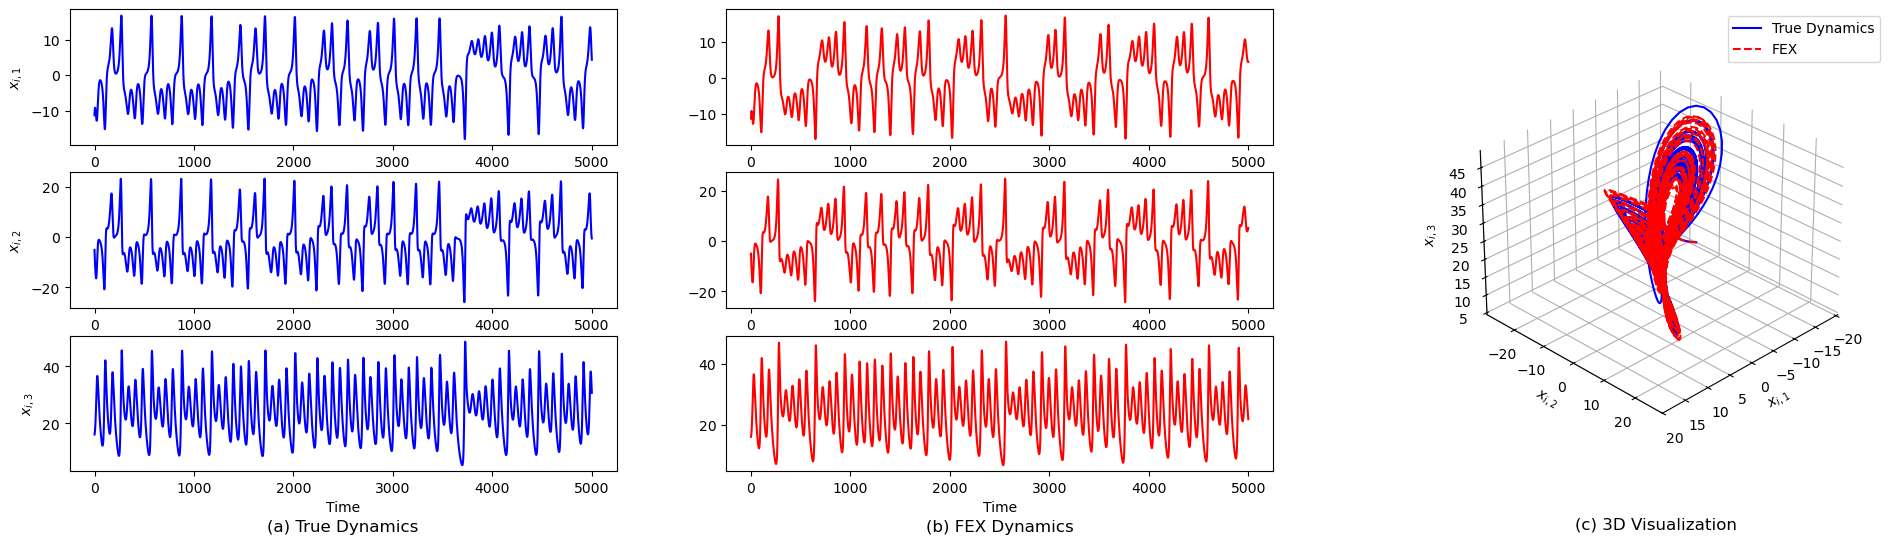

In [ ]:
predicted_states = torch.zeros(timesteps + 1, timeseries.size(1), timeseries.size(2), device=device)
predicted_states[0] = timeseries[0]
dt = 0.01
with torch.no_grad():
    for t in range(timesteps):
        state = predicted_states[t]

        dx_dt = torch.cat([
            dimx_fex.predict(state, adj_matrix.to(device)), # dimx_fex.predict(state, adj_matrix),
            dimy_fex.predict(state),
            dimz_fex.predict(state)
        ], dim=-1)

        predicted_states[t+1] = state + dt * dx_dt

        if not torch.isfinite(predicted_states[t+1]).all():
            print(f"Non-finite state at timestep {t + 1}")
            break
        
from FEX.utils.plots import plot_dynamics

node = 80
fig = plot_dynamics(timeseries[:, node, 0].cpu(), timeseries[:, node, 1].cpu(), timeseries[:, node, 2].cpu(), predicted_states[:, node, :].cpu(), elev=15, azim=75)
fig.show()


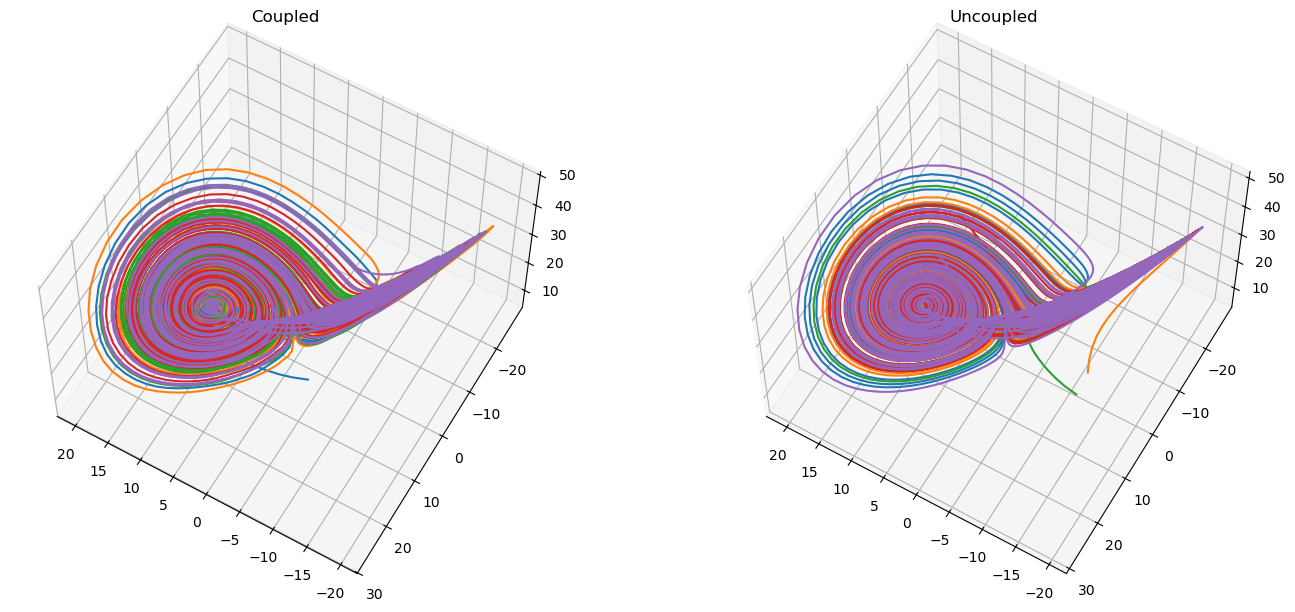

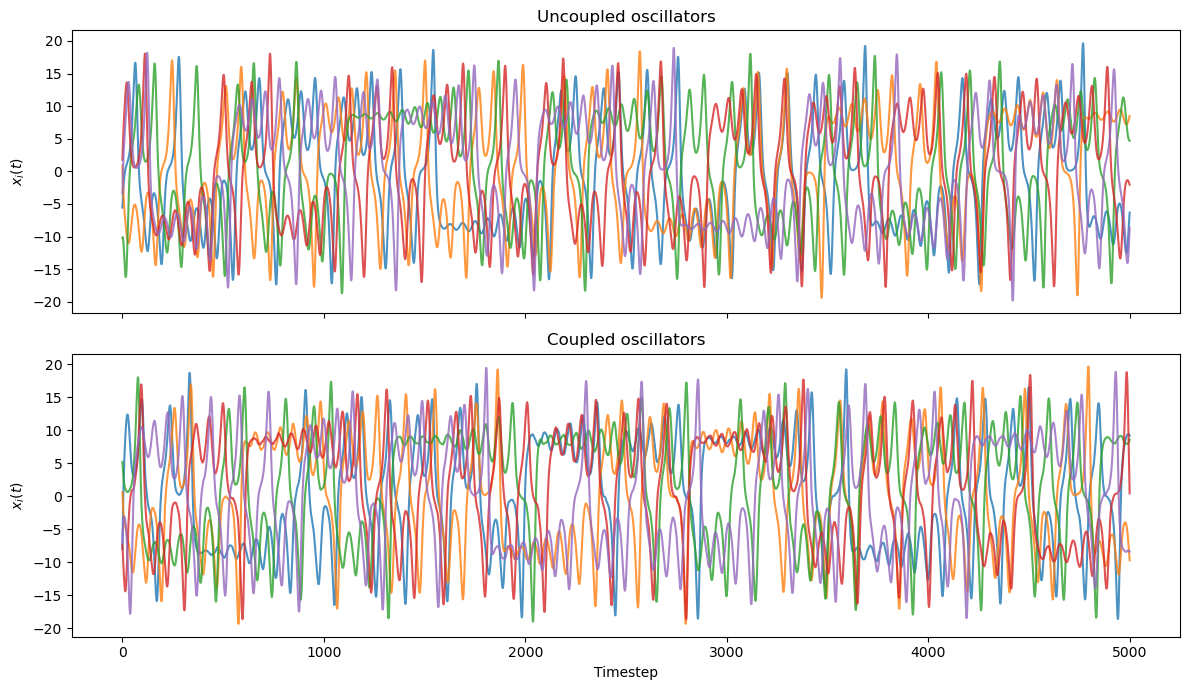

In [ ]:
import matplotlib.pyplot as plt

adj_matrix = make_adjacency(100, 0.45, device="cpu")

coupled_data, coupled_derivatives = make_data(
    num_samples=timesteps,
    adjacency=adj_matrix,
    coupling=0.6,
)

uncoupled_data, uncoupled_derivatives = make_data(
    num_samples=timesteps,
    adjacency=adj_matrix,
    coupling=0.0,
)

# axs has shape (2, 5)
fig, axs = plt.subplots(1, 2, figsize=(15, 6), subplot_kw={"projection": "3d"})
num_nodes = 5
for node in range(num_nodes):
    axs[0].plot(
        coupled_data[:, node * 5, 0],
        coupled_data[:, node * 5, 1],
        coupled_data[:, node * 5, 2],
    )
axs[0].set_title(f"Coupled")
axs[0].view_init(elev=60, azim=120)
for node in range(num_nodes):
    axs[1].plot(
        uncoupled_data[:, node * 5, 0],
        uncoupled_data[:, node * 5, 1],
        uncoupled_data[:, node * 5, 2],
    )
axs[1].set_title(f"Uncoupled")
axs[1].view_init(elev=60, azim=120)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for node in range(5):
    axs[0].plot(uncoupled_data[:, node, 0], alpha=0.8)

for node in range(5):
    axs[1].plot(coupled_data[:, node, 0], alpha=0.8)

axs[0].set_title("Uncoupled oscillators")
axs[1].set_title("Coupled oscillators")

axs[0].set_ylabel("$x_i(t)$")
axs[1].set_ylabel("$x_i(t)$")
axs[1].set_xlabel("Timestep")

plt.tight_layout()
plt.show()